In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import json
BLOCK_RANDOM12_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/attn_maps/attnmap_block_random_12trial.jsonl"
BLOCK_RANDOM6_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_block_random_6trial_llama.jsonl"
RANDOM12_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_random_12trial_llama.jsonl"
RANDOM6_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/attn_maps/attnmap_random_6trial.jsonl"

def identify_shape(path):
  with open(path) as f:
    for i, line in enumerate(f):
      data = json.loads(line)
      attnmap = data["attnmap"]
      torch_attnmap = torch.tensor(attnmap)
      print(f"path name: {path}\n",torch_attnmap.shape)
      break

identify_shape(BLOCK_RANDOM12_PATH)
identify_shape(BLOCK_RANDOM6_PATH)
identify_shape(RANDOM12_PATH)
identify_shape(RANDOM6_PATH)

path name: /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/attn_maps/attnmap_block_random_12trial.jsonl
 torch.Size([12, 20, 6, 32])
path name: /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_block_random_6trial_llama.jsonl
 torch.Size([6, 20, 6, 32])
path name: /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_random_12trial_llama.jsonl
 torch.Size([12, 20, 6, 32])
path name: /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/attn_maps/attnmap_random_6trial.jsonl
 torch.Size([6, 20, 6, 32])


In [13]:
import json
import numpy as np
import matplotlib.pyplot as plt

def analyze_and_plot_comparative_ranks(file_paths, labels, num_samples_to_read=600,
                                     selected_indices=[0, 2, 4, 6, 8, 9, 10, 12, 14, 16, 18, 19], num_docs=20):
    """
    3つのファイルからGold文書の順位を集計し、比較グラフを描画する。
    """
    if len(file_paths) != 3:
        raise ValueError("file_paths and labels must contain exactly 3 items.")

    all_method_counts = []

    for path, label in zip(file_paths, labels):
        gold_ranks = []
        processed_count = 0

        print(f"Analyzing {label}...")
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                if processed_count >= num_samples_to_read:
                    break

                data = json.loads(line)
                attn_array = np.array(data["attnmap"])

                # 巡回シフト等の20回試行を6回分にフィルタリング
                if attn_array.shape[0] == 20 and selected_indices is not None:
                    attn_array = attn_array[selected_indices, :, :, :]

                # 全軸(Trial, Layer, Head)の総和を計算 -> [Doc: 20]
                doc_scores = attn_array.sum(axis=(0, 2, 3))

                # 順位の算出 (降順)
                sorted_indices = np.argsort(-doc_scores)
                rank = np.where(sorted_indices == 0)[0][0]
                gold_ranks.append(rank)
                processed_count += 1

        # 0〜19の各ランクの出現頻度をカウント
        counts = np.zeros(num_docs)
        for r in gold_ranks:
            counts[r] += 1
        all_method_counts.append(counts)

    # --- 描画処理 ---
    plt.figure(figsize=(16, 7))
    x = np.arange(num_docs)
    width = 0.25  # 各棒の幅
    colors = ['#4A90E2', '#50E3C2', '#F5A623']  # 青、エメラルド、オレンジ

    # 各手法の棒をオフセットさせて描画
    for i in range(3):
        offset = (i - 1) * width
        plt.bar(x + offset, all_method_counts[i], width,
                label=labels[i], color=colors[i], edgecolor='black', alpha=0.8)

    plt.title(f'Comparison of Gold Document Rank Distribution\n(Aggregated over {num_samples_to_read} samples per method)', fontsize=16)
    plt.xlabel('Rank of Gold Document (0 = Top-1, 19 = Bottom-1)', fontsize=14)
    plt.ylabel('Number of Samples', fontsize=14)
    plt.xticks(x)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.legend(fontsize=12)

    # 棒の上に数値を表示 (視認性のため、ある程度の頻度がある場合のみ)
    for i in range(3):
        offset = (i - 1) * width
        for idx, val in enumerate(all_method_counts[i]):
            if val > 0:
                plt.text(idx + offset, val + 0.2, int(val),
                         ha='center', va='bottom', fontsize=8, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return all_method_counts


Analyzing Cyclic Shift...
Analyzing Random Shuffle...
Analyzing Block Permutation...


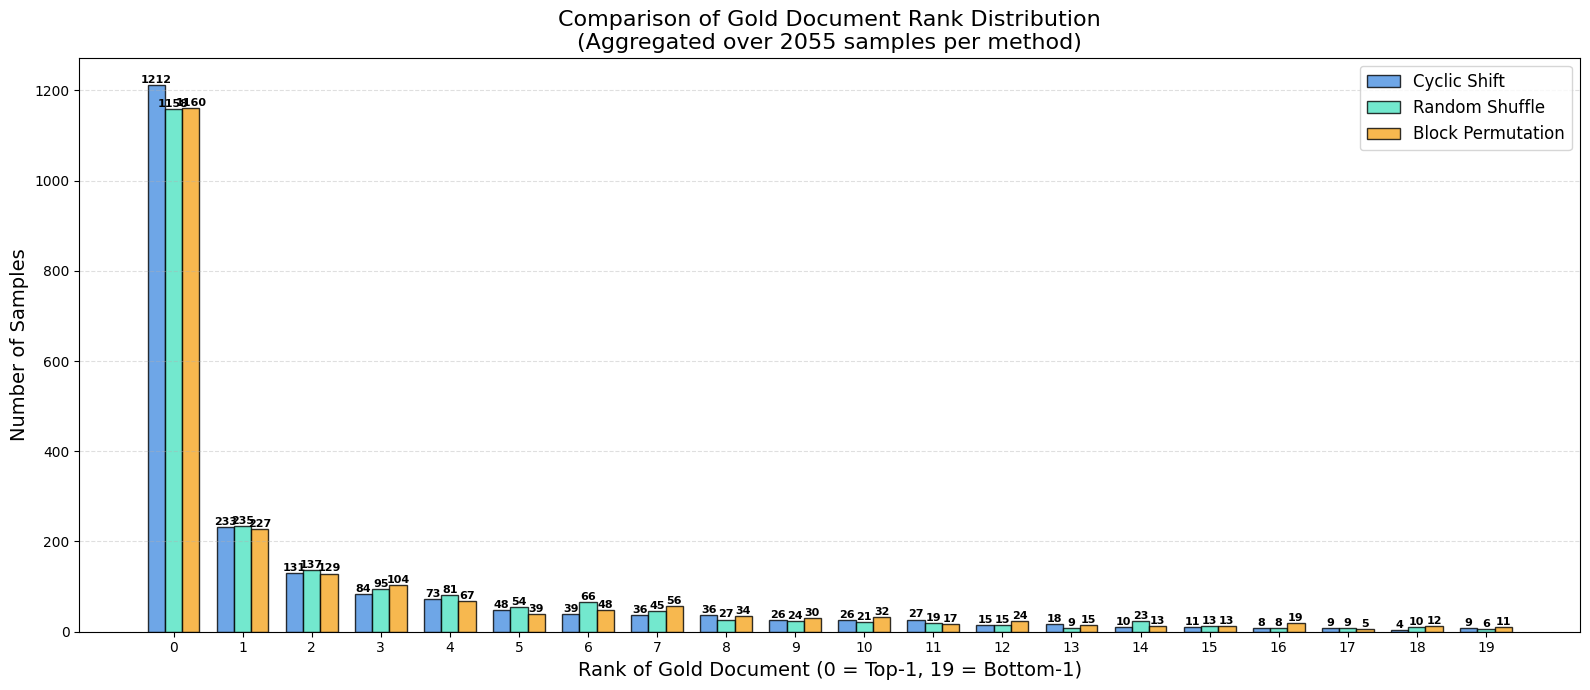

Analyzing Cyclic Shift...
Analyzing Random Shuffle...
Analyzing Block Permutation...


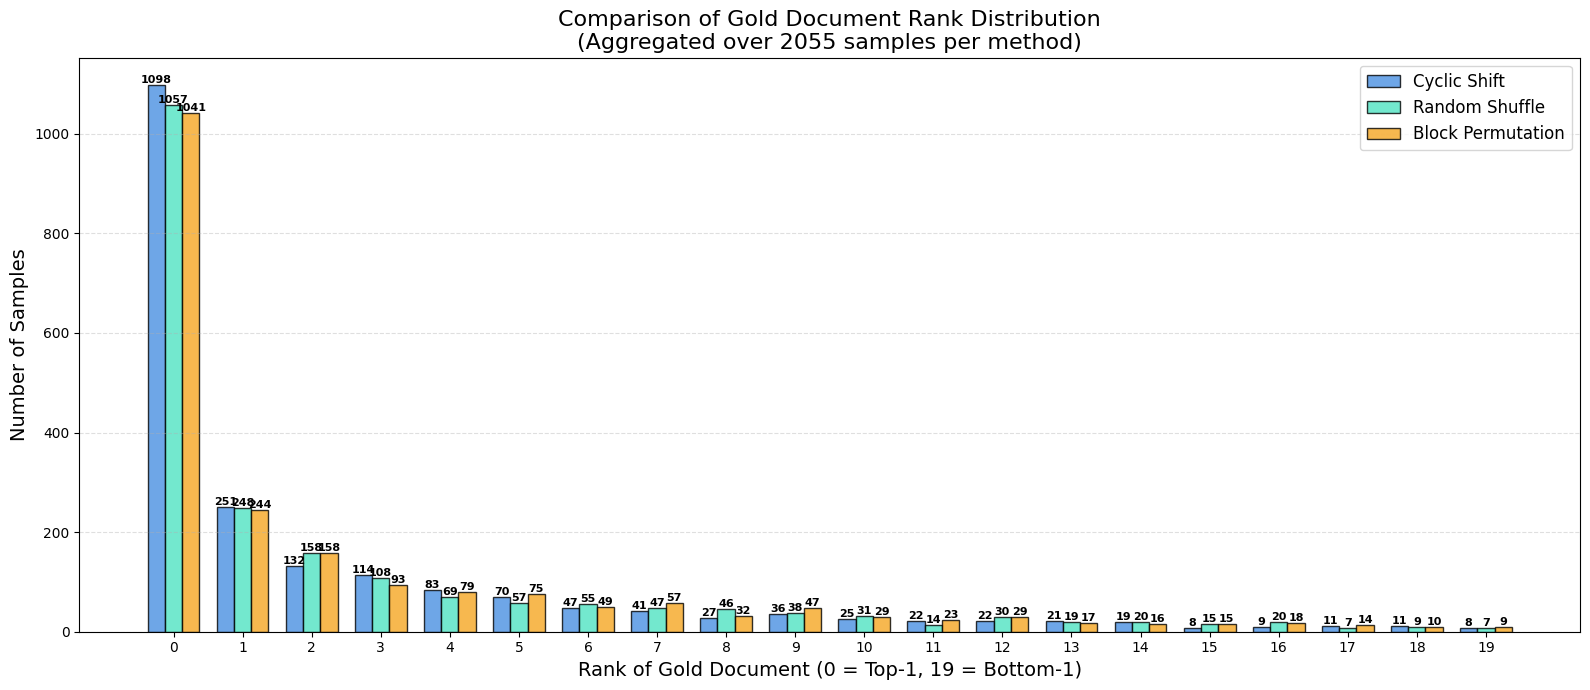

In [14]:
# --- 実行 ---
# -- 12 trial --
SHIFT_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_shift_bm25_llama.jsonl"
RANDOM12_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_random_12trial_llama.jsonl"
BLOCK12_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_block_random_12trial_llama.jsonl"

llama_file_paths = [SHIFT_PATH, RANDOM12_PATH, BLOCK12_PATH]
labels = ["Cyclic Shift", "Random Shuffle", "Block Permutation"]

counts = analyze_and_plot_comparative_ranks(llama_file_paths, labels, num_samples_to_read=2055, selected_indices=[0, 2, 4, 6, 8, 9, 10, 12, 14, 16, 18, 19])

# -- 6 trial --
SHIFT_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_shift_bm25_llama.jsonl"
RANDOM6_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_random_6trial_llama.jsonl"
BLOCK6_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_block_random_6trial_llama.jsonl"

llama_file_paths = [SHIFT_PATH, RANDOM6_PATH, BLOCK6_PATH]
labels = ["Cyclic Shift", "Random Shuffle", "Block Permutation"]
counts = analyze_and_plot_comparative_ranks(llama_file_paths, labels, num_samples_to_read=2055, selected_indices=[0, 4, 8, 12, 16, 19])

Analyzing Cyclic Shift...
Analyzing Random Shuffle...
Analyzing Block Permutation...


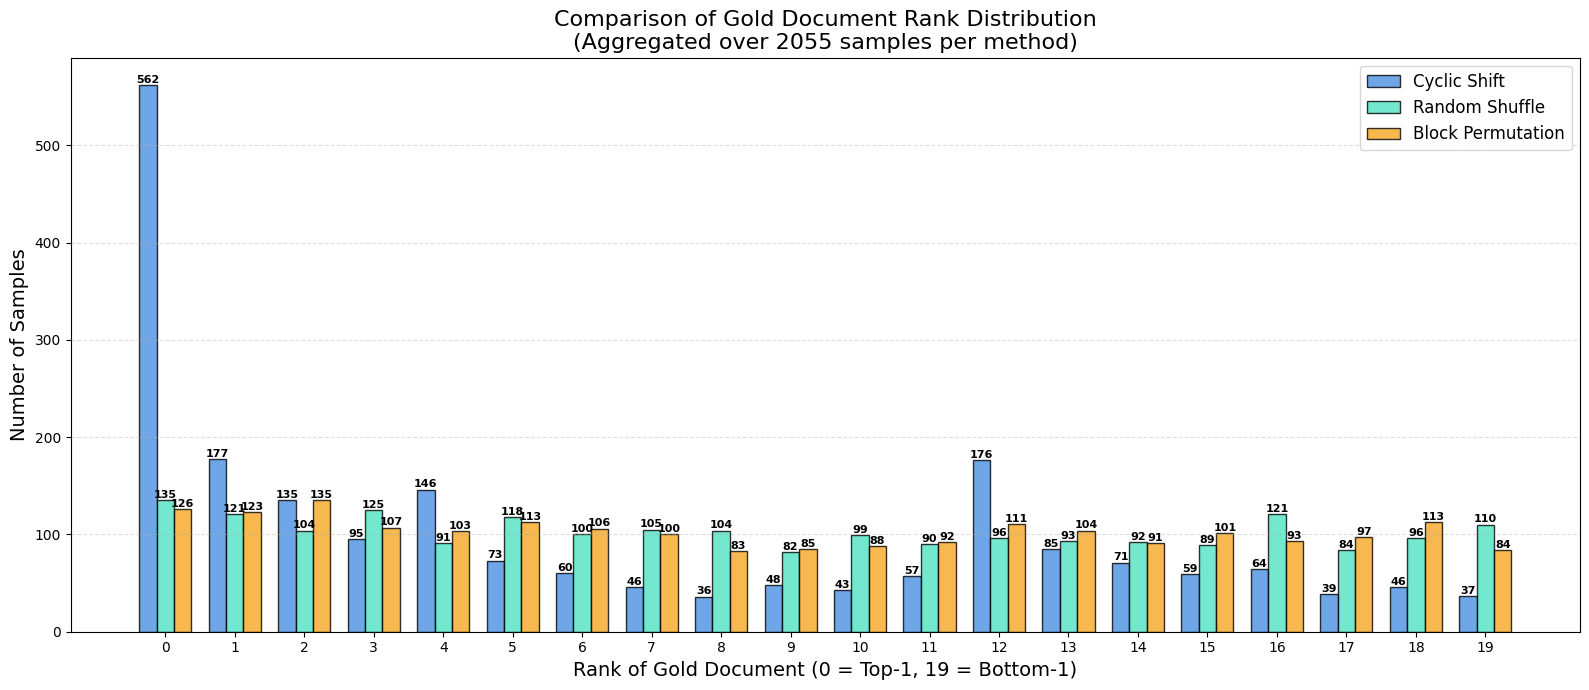

Analyzing Cyclic Shift...
Analyzing Random Shuffle...
Analyzing Block Permutation...


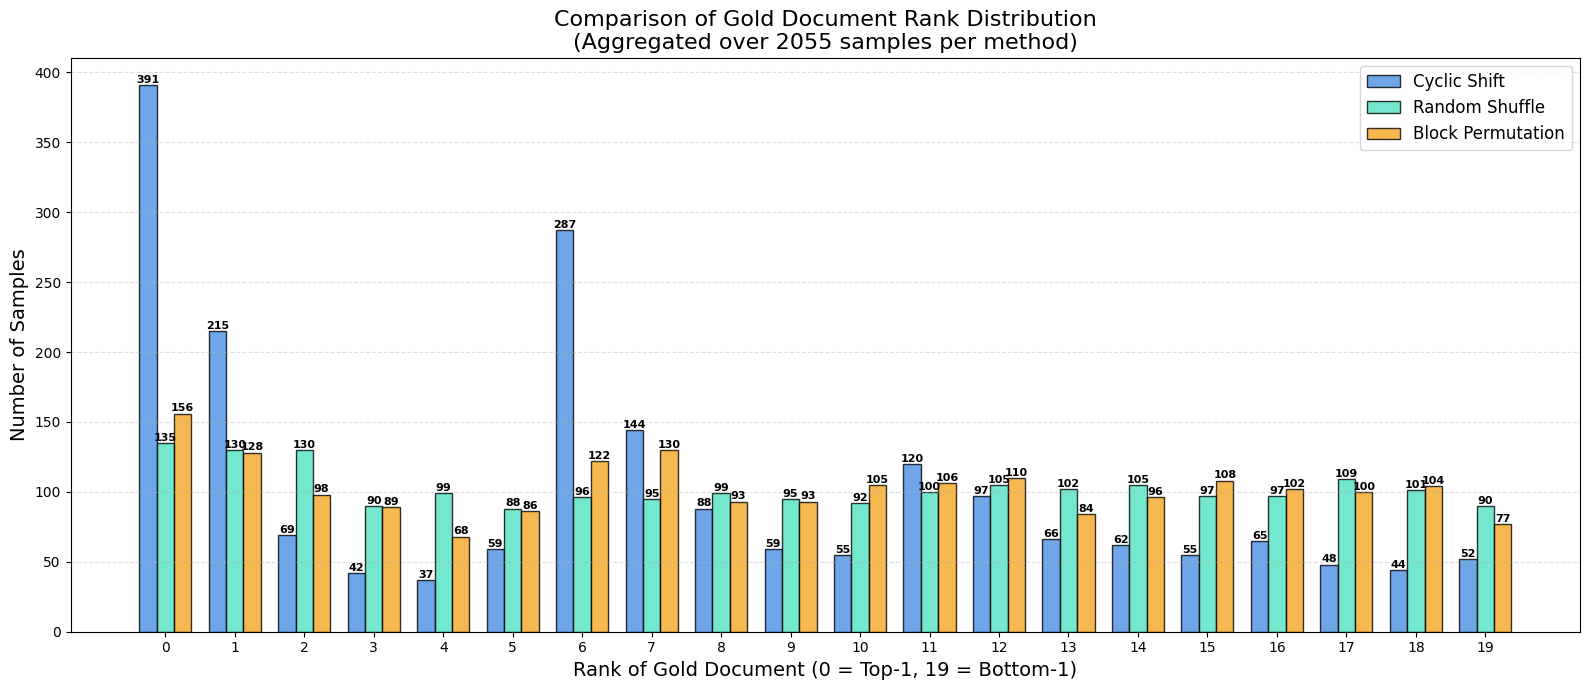

In [16]:
# --- 実行 ---
# -- 12 trial --
SHIFT_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_shift_bm25_vicuna-16k.jsonl"
RANDOM12_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_random_12trial_vicuna-16k.jsonl"
BLOCK12_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_block_random_12trial_vicuna-16k.jsonl"

vicuna_file_paths = [SHIFT_PATH, RANDOM12_PATH, BLOCK12_PATH]
labels = ["Cyclic Shift", "Random Shuffle", "Block Permutation"]

counts = analyze_and_plot_comparative_ranks(vicuna_file_paths, labels, num_samples_to_read=2055, selected_indices=[0, 2, 4, 6, 8, 9, 10, 12, 14, 16, 18, 19])

# -- 6 trial --
SHIFT_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_shift_bm25_vicuna-16k.jsonl"
RANDOM6_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_random_6trial_vicuna-16k.jsonl"
BLOCK6_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_block_random_6trial_vicuna-16k.jsonl"

vicuna_file_paths = [SHIFT_PATH, RANDOM6_PATH, BLOCK6_PATH]
labels = ["Cyclic Shift", "Random Shuffle", "Block Permutation"]
counts = analyze_and_plot_comparative_ranks(vicuna_file_paths, labels, num_samples_to_read=2055, selected_indices=[0, 4, 8, 12, 16, 19])


In [10]:
from tqdm import tqdm
SHIFT_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_shift_bm25_vicuna-16k.jsonl"
RANDOM6_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_random_6trial_vicuna-16k.jsonl"
BLOCK6_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_block_random_6trial_vicuna-16k.jsonl"

vicuna_file_paths = [SHIFT_PATH, RANDOM6_PATH, BLOCK6_PATH]

for i in vicuna_file_paths:
  print(i, ": ")
  with open(i, "r") as f:
    print(sum(1 for _ in tqdm(f)))

/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_shift_bm25_vicuna-16k.jsonl : 


2055it [00:57, 35.83it/s]


2055
/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_random_6trial_vicuna-16k.jsonl : 


2055it [00:09, 207.36it/s]


2055
/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_block_random_6trial_vicuna-16k.jsonl : 


2055it [00:08, 252.77it/s]

2055


Analyzing ranks in: /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_shift_bm25_llama.jsonl


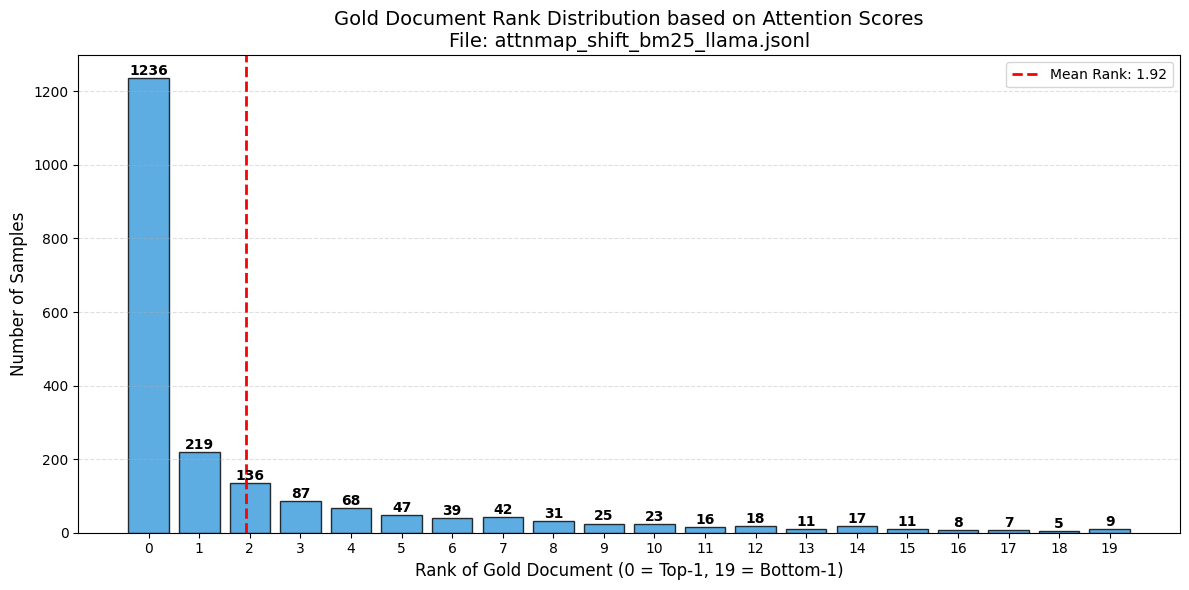

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt

def analyze_gold_rank_distribution(file_path, selected_indices=[0, 4, 8, 12, 16, 19]):
    """
    JSONLからアテンション重みを読み込み、Gold文書(index 0)の順位分布をプロットする
    """
    gold_ranks = []
    processed_count = 0
    num_docs = 20

    print(f"Analyzing ranks in: {file_path}")
    with open(file_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            # if i >= 100: break
            data = json.loads(line)
            # attnmap: [Trial, Doc, Layer, Head]
            attn_array = np.array(data["attnmap"])

            # 1. 試行のフィルタリング (20試行ある場合のみ実施)
            if attn_array.shape[0] == 20 and selected_indices is not None:
                attn_array = attn_array[selected_indices, :, :, :]

            # 2. 全軸(Trial, Layer, Head)の総和を計算 -> [Doc: 20]
            doc_scores = attn_array.sum(axis=(0, 2, 3))

            # 3. 順位の算出
            # 降順ソートした際のインデックスを取得
            # 例: [2, 0, 1...] であれば、index 2が1位、index 0が2位
            sorted_indices = np.argsort(-doc_scores)

            # 4. Gold文書(index 0)が順位表のどこにあるかを取得
            # 0が含まれる位置がランク (0-indexed)
            rank = np.where(sorted_indices == 0)[0][0]
            gold_ranks.append(rank)
            processed_count += 1

    # ヒストグラムの描画
    plot_rank_histogram(gold_ranks, num_docs, file_path.split('/')[-1])

    return gold_ranks

def plot_rank_histogram(gold_ranks, total_docs_count, filename):
    """
    Gold文書の順位ヒストグラムを描画
    """
    plt.figure(figsize=(12, 6))

    # 0から19の範囲でヒストグラムを作成
    counts, bins, patches = plt.hist(
        gold_ranks,
        bins=np.arange(total_docs_count + 1) - 0.5,
        rwidth=0.8,
        color='#3498db',
        edgecolor='black',
        alpha=0.8
    )

    # 平均順位の計算
    mean_rank = np.mean(gold_ranks)
    median_rank = np.median(gold_ranks)

    # グラフの装飾
    plt.title(f'Gold Document Rank Distribution based on Attention Scores\nFile: {filename}', fontsize=14)
    plt.xlabel('Rank of Gold Document (0 = Top-1, 19 = Bottom-1)', fontsize=12)
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xticks(range(total_docs_count))
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    # 統計情報の表示
    plt.axvline(mean_rank, color='red', linestyle='dashed', linewidth=2, label=f'Mean Rank: {mean_rank:.2f}')

    # バーの上に数値を表示
    for count, x in zip(counts, range(total_docs_count)):
        if count > 0:
            plt.text(x, count + 0.1, int(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.legend()
    plt.tight_layout()
    plt.show()

# 実行例
SHIFT_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_attn_maps/attnmap_shift_bm25_llama.jsonl"
RANDOM_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/attn_maps/attnmap_random_6trial.jsonl"
BLOCK_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/attn_maps/attnmap_block_random_6trial.jsonl"
gold_ranks = analyze_gold_rank_distribution(SHIFT_PATH, selected_indices=None)
# gold_ranks = analyze_gold_rank_distribution(SHIFT_PATH, selected_indices=[0, 2, 4, 6, 8, 10, 11, 12, 14, 16, 18, 19])
# gold_ranks = analyze_gold_rank_distribution(RANDOM_PATH, selected_indices=None)
# gold_ranks = analyze_gold_rank_distribution(BLOCK_PATH, selected_indices=None)

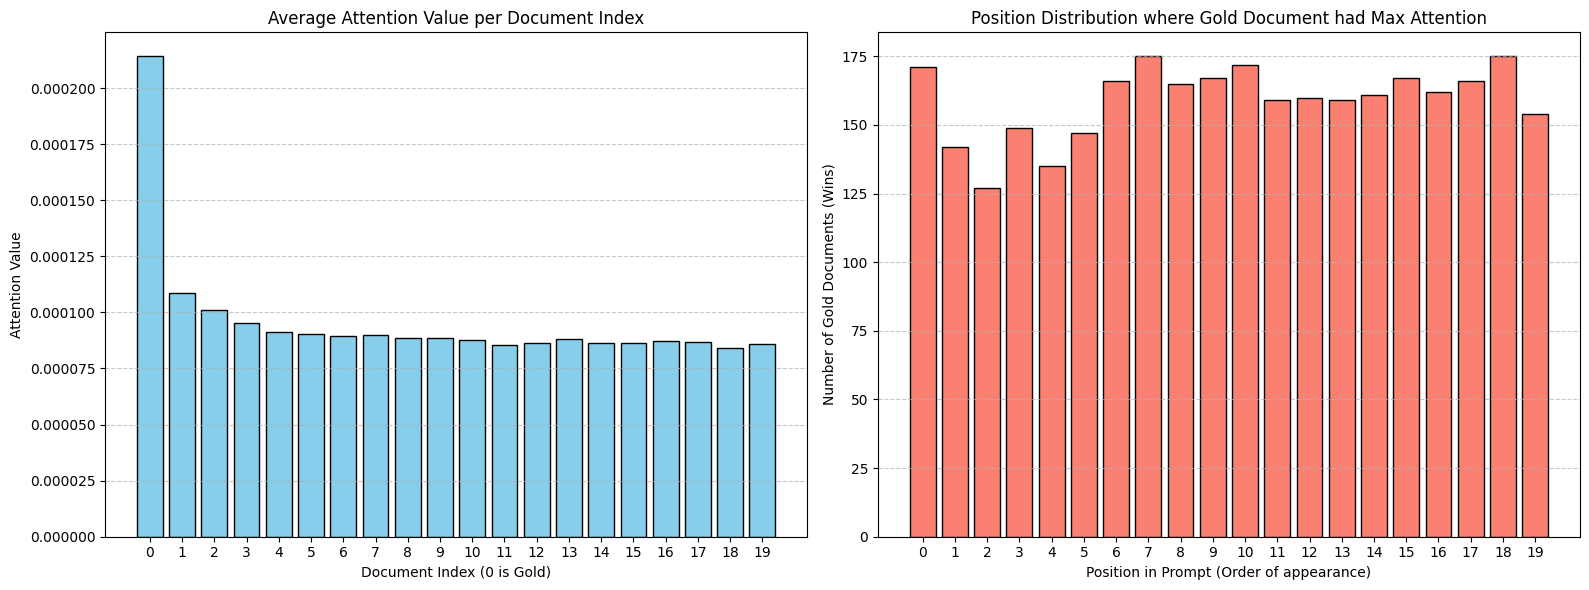

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

def analyze_attention_jsonl(file_path, num_docs=20):
    # 集計用
    all_docs_total_attn = np.zeros(num_docs)  # 文書インデックスごとの合計
    gold_pos_counts = np.zeros(num_docs)      # Gold文書が「最高のアテンション」を得た時のプロンプト内順位
    total_samples = 0

    with open(file_path, "r") as f:
        for line in f:
            data = json.loads(line)
            # attnmap: [Trial, Doc, Layer, Head] のリスト
            attn_array = np.array(data["attnmap"])
            num_trials = attn_array.shape[0]
            total_samples += 1

            # --- 分析1: 各文書インデックスの平均値 (全試行・全層・全ヘッド) ---
            # [Trial, Doc, Layer, Head] -> [Doc]
            avg_per_doc = attn_array.mean(axis=(0, 2, 3))
            all_docs_total_attn += avg_per_doc

            # --- 分析2: Gold文書(Index 0)の順序分布ヒストグラム ---
            # 各試行において「どの位置にいた時のGold文書が最強だったか」を集計
            for trial_idx in range(num_trials):
                # 試行内の各文書のスコア (Layer, Headで平均)
                doc_scores_in_trial = attn_array[trial_idx].mean(axis=(1, 2))

                # その試行での勝者（最大アテンション）がGold文書(Index 0)だった場合
                if np.argmax(doc_scores_in_trial) == 0:
                    # Gold文書がプロンプト内のどこに配置されていたかを算出
                    # shiftの仕様: shifted = docs[trial_idx:] + docs[:trial_idx]
                    # 文書0の物理位置 j は (0 - trial_idx) % num_docs
                    prompt_pos = (0 - trial_idx) % num_docs
                    gold_pos_counts[prompt_pos] += 1

    # 平均の算出
    final_avg_attn = all_docs_total_attn / total_samples

    # --- 描画 ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # 1. 各文書インデックスの値の大きさ
    ax1.bar(range(num_docs), final_avg_attn, color="skyblue", edgecolor="black")
    ax1.set_title("Average Attention Value per Document Index")
    ax1.set_xlabel("Document Index (0 is Gold)")
    ax1.set_ylabel("Attention Value")
    ax1.set_xticks(range(num_docs))
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # 2. Gold文書の順序分布ヒストグラム
    ax2.bar(range(num_docs), gold_pos_counts, color="salmon", edgecolor="black")
    ax2.set_title("Position Distribution where Gold Document had Max Attention")
    ax2.set_xlabel("Position in Prompt (Order of appearance)")
    ax2.set_ylabel("Number of Gold Documents (Wins)")
    ax2.set_xticks(range(num_docs))
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# 使用例
OUTPUT_PATH = f"/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/attn_maps/attnmap_shift_bm25.jsonl"
analyze_attention_jsonl(OUTPUT_PATH)

In [3]:
# 回答のEMスコア
%pip install xopen

import json
import re
import string
from typing import List
from xopen import xopen

def normalize_answer(s: str) -> str:
    """
    NLPの標準的な回答正規化: 小文字化、句読点除去、冠詞(a, an, the)の除去、余分な空白の修正
    """
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)

    def white_space_fix(text):
        return ' '.join(text.split())

    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))

def best_subspan_em(prediction: str, ground_truths: List[str]) -> float:
    """
    予測文の中に、正解ラベルのいずれかが正規化された状態で含まれているか判定する
    """
    normalized_prediction = normalize_answer(prediction)
    for ground_truth in ground_truths:
        normalized_ground_truth = normalize_answer(ground_truth)
        # prediction の中に ground_truth が含まれているか（Subspan Match）
        if normalized_ground_truth.lower() in normalized_prediction.lower():
            return 1
    return 0

def evaluate_results(file_path: str):
    """
    JSONLファイルを読み込み、平均スコアを計算する
    """
    scores = []

    print(f"Evaluating: {file_path}")

    with xopen(file_path, "r") as f:
        for i, line in enumerate(f):
            # if i < 600: continue
            try:
                data = json.loads(line)
                prediction = data.get("prediction", "")
                ground_truths = data.get("answers", [])

                if not ground_truths:
                    continue

                score = best_subspan_em(prediction, ground_truths)
                scores.append(score)
            except json.JSONDecodeError:
                continue

    if not scores:
        print("No valid data found in the file.")
        return 0.0

    # 平均値の計算
    final_score = (sum(scores) / len(scores)) * 100
    print("-" * 30)
    print(f"Total Samples: {len(scores)}")
    print(f"Average EM: {final_score:.2f}%")
    print("-" * 30)

    return final_score

def get_path(sampling, trial, model):
  return f"/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_{sampling}_{trial}trial_{model}.jsonl"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.4/132.4 kB 12.1 MB/s eta 0:00:00


In [16]:
!tail -n +601 "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_existing_no_reverse_llama.jsonl" > "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_existing_no_reverse_llama_fixed.jsonl"
!tail -n +601 "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_baseline_llama.jsonl" > "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_baseline_llama_fixed.jsonl"

In [17]:
# --- 実行例 ---
for trial in [6, 12]:
  for sampling in ["shift_bm25", "random", "block_random"]:
    path = get_path(sampling=sampling, trial=trial, model="llama")
    em_score = evaluate_results(path)

EXISTING_LLAMA_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_existing_no_reverse_llama_fixed.jsonl"
BASELINE_LLAMA_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_baseline_llama_fixed.jsonl"

em_score = evaluate_results(EXISTING_LLAMA_PATH)
em_score = evaluate_results(BASELINE_LLAMA_PATH)

Evaluating: /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_shift_bm25_6trial_llama.jsonl
------------------------------
Total Samples: 2055
Average EM: 49.88%
------------------------------
Evaluating: /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_random_6trial_llama.jsonl
------------------------------
Total Samples: 2055
Average EM: 50.02%
------------------------------
Evaluating: /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_block_random_6trial_llama.jsonl
------------------------------
Total Samples: 2055
Average EM: 48.95%
------------------------------
Evaluating: /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_shift_bm25_12trial_llama.jsonl
------------------------------
Total Samples: 2055
Average EM: 52.65%
------------

In [4]:
# --- 実行例 ---
for trial in [6, 12]:
  for sampling in ["shift_bm25", "random", "block_random"]:
    path = get_path(sampling=sampling, trial=trial, model="vicuna-16k")
    em_score = evaluate_results(path)

EXISTING_VICUNA_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_existing_no_reverse_vicuna-16k.jsonl"
BASELINE_VICUNA_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_baseline_vicuna-16k.jsonl"
em_score = evaluate_results(EXISTING_VICUNA_PATH)
em_score = evaluate_results(BASELINE_VICUNA_PATH)

Evaluating: /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_shift_bm25_6trial_vicuna-16k.jsonl
------------------------------
Total Samples: 2055
Average EM: 52.55%
------------------------------
Evaluating: /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_random_6trial_vicuna-16k.jsonl
------------------------------
Total Samples: 2055
Average EM: 51.09%
------------------------------
Evaluating: /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_block_random_6trial_vicuna-16k.jsonl
------------------------------
Total Samples: 2055
Average EM: 51.34%
------------------------------
Evaluating: /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_shift_bm25_12trial_vicuna-16k.jsonl
------------------------------
Total Samples: 2055
Average EM:

In [5]:
import numpy as np
from itertools import combinations
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

def get_score_vector(file_path: str, has_validation):
    """
    ファイルから判定結果（0 or 1）のベクトルを取得する
    """
    scores = []
    with xopen(file_path, "r") as f:
        for i, line in enumerate(f):
            # if has_validation: continue
            try:
                data = json.loads(line)
                prediction = data.get("prediction", "")
                ground_truths = data.get("answers", [])

                scores.append(best_subspan_em(prediction, ground_truths))
            except json.JSONDecodeError:
                continue
    return np.array(scores)

# 1. すべての結果を収集
all_results = {}

# 既存・ベースラインの追加
EXISTING_LLAMA_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_existing_no_reverse_llama_fixed.jsonl"
BASELINE_LLAMA_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_baseline_llama_fixed.jsonl"
all_results["existing_llama"] = get_score_vector(EXISTING_LLAMA_PATH, True)
all_results["baseline_llama"] = get_score_vector(BASELINE_LLAMA_PATH, True)

# 実験グループの追加
for trial in [6, 12]:
    for sampling in ["shift_bm25", "random", "block_random"]:
        name = f"{sampling}_{trial}t"
        path = get_path(sampling=sampling, trial=trial, model="llama")
        all_results[name] = get_score_vector(path, False)

# 2. 全ペアに対してマクネマー検定を実行
pairs = list(combinations(all_results.keys(), 2))
p_values = []
pair_names = []

for name1, name2 in pairs:
    vec1 = all_results[name1]
    vec2 = all_results[name2]

    # サンプル数が一致していることを確認
    assert len(vec1) == len(vec2), f"Length mismatch between {name1} and {name2}, {len(vec1), len(vec2)}"

    # 2x2 分割表の作成
    # [[両方正解, vec1のみ正解], [vec2のみ正解, 両方不正解]]
    table = np.zeros((2, 2))
    table[0, 0] = np.sum((vec1 == 1) & (vec2 == 1))
    table[0, 1] = np.sum((vec1 == 1) & (vec2 == 0))
    table[1, 0] = np.sum((vec1 == 0) & (vec2 == 1))
    table[1, 1] = np.sum((vec1 == 0) & (vec2 == 0))

    # マクネマー検定 (サンプルサイズが小さい可能性を考慮し exact=True)
    result = mcnemar(table, exact=True)
    p_values.append(result.pvalue)
    pair_names.append(f"{name1} vs {name2}")

# 3. Holm補正を適用
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='holm')

# 結果の表示
print(f"{'Comparison':<40} | {'Raw P':<10} | {'Adj P':<10} | {'Reject H0'}")
print("-" * 80)
for i in range(len(pairs)):
    print(f"{pair_names[i]:<40} | {p_values[i]:.4f} | {p_adjusted[i]:.4f} | {reject[i]}")

Comparison                               | Raw P      | Adj P      | Reject H0
--------------------------------------------------------------------------------
existing_llama vs baseline_llama         | 0.0219 | 0.2825 | False
existing_llama vs shift_bm25_6t          | 0.0217 | 0.2825 | False
existing_llama vs random_6t              | 0.0172 | 0.2404 | False
existing_llama vs block_random_6t        | 0.1445 | 1.0000 | False
existing_llama vs shift_bm25_12t         | 0.0000 | 0.0001 | True
existing_llama vs random_12t             | 0.0003 | 0.0059 | True
existing_llama vs block_random_12t       | 0.0001 | 0.0015 | True
baseline_llama vs shift_bm25_6t          | 0.0000 | 0.0003 | True
baseline_llama vs random_6t              | 0.0000 | 0.0004 | True
baseline_llama vs block_random_6t        | 0.0006 | 0.0120 | True
baseline_llama vs shift_bm25_12t         | 0.0000 | 0.0000 | True
baseline_llama vs random_12t             | 0.0000 | 0.0000 | True
baseline_llama vs block_random_12t       | 0

In [12]:
import numpy as np
from itertools import combinations
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

def get_score_vector(file_path: str, has_validation):
    """
    ファイルから判定結果（0 or 1）のベクトルを取得する
    """
    scores = []
    with xopen(file_path, "r") as f:
        for i, line in enumerate(f):
            try:
                data = json.loads(line)
                prediction = data.get("prediction", "")
                ground_truths = data.get("answers", [])

                scores.append(best_subspan_em(prediction, ground_truths))
            except json.JSONDecodeError:
                continue
    return np.array(scores)

# 1. すべての結果を収集
all_results = {}

# 既存・ベースラインの追加
EXISTING_VICUNA_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_existing_no_reverse_vicuna-16k.jsonl"
BASELINE_VICUNA_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_baseline_vicuna-16k.jsonl"
all_results["existing_vicuna"] = get_score_vector(EXISTING_VICUNA_PATH, True)
all_results["baseline_vicuna"] = get_score_vector(BASELINE_VICUNA_PATH, True)

# 実験グループの追加
for trial in [6, 12]:
    for sampling in ["shift_bm25", "random", "block_random"]:
        name = f"{sampling}_{trial}t"
        path = get_path(sampling=sampling, trial=trial, model="vicuna-16k")
        all_results[name] = get_score_vector(path, True)

# 2. 全ペアに対してマクネマー検定を実行
pairs = list(combinations(all_results.keys(), 2))
p_values = []
pair_names = []

for name1, name2 in pairs:
    vec1 = all_results[name1]
    vec2 = all_results[name2]

    # サンプル数が一致していることを確認
    assert len(vec1) == len(vec2), f"Length mismatch between {name1} and {name2} {len(vec1), len(vec2)}"

    # 2x2 分割表の作成
    # [[両方正解, vec1のみ正解], [vec2のみ正解, 両方不正解]]
    table = np.zeros((2, 2))
    table[0, 0] = np.sum((vec1 == 1) & (vec2 == 1))
    table[0, 1] = np.sum((vec1 == 1) & (vec2 == 0))
    table[1, 0] = np.sum((vec1 == 0) & (vec2 == 1))
    table[1, 1] = np.sum((vec1 == 0) & (vec2 == 0))

    # マクネマー検定 (サンプルサイズが小さい可能性を考慮し exact=True)
    result = mcnemar(table, exact=True)
    p_values.append(result.pvalue)
    pair_names.append(f"{name1} vs {name2}")

# 3. Holm補正を適用
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='holm')

# 結果の表示
print(f"{'Comparison':<40} | {'Raw P':<10} | {'Adj P':<10} | {'Reject H0'}")
print("-" * 80)
for i in range(len(pairs)):
    print(f"{pair_names[i]:<40} | {p_values[i]:.4f} | {p_adjusted[i]:.4f} | {reject[i]}")

Comparison                               | Raw P      | Adj P      | Reject H0
--------------------------------------------------------------------------------
existing_vicuna vs baseline_vicuna       | 0.0000 | 0.0000 | True
existing_vicuna vs shift_bm25_6t         | 0.0000 | 0.0000 | True
existing_vicuna vs random_6t             | 0.0008 | 0.0151 | True
existing_vicuna vs block_random_6t       | 0.0003 | 0.0053 | True
existing_vicuna vs shift_bm25_12t        | 0.0000 | 0.0000 | True
existing_vicuna vs random_12t            | 0.0011 | 0.0194 | True
existing_vicuna vs block_random_12t      | 0.0001 | 0.0031 | True
baseline_vicuna vs shift_bm25_6t         | 0.1629 | 1.0000 | False
baseline_vicuna vs random_6t             | 0.0074 | 0.1107 | False
baseline_vicuna vs block_random_6t       | 0.0120 | 0.1681 | False
baseline_vicuna vs shift_bm25_12t        | 0.1014 | 1.0000 | False
baseline_vicuna vs random_12t            | 0.0030 | 0.0473 | True
baseline_vicuna vs block_random_12t      | 0

In [8]:
import json
import numpy as np
import os
from itertools import combinations
from xopen import xopen
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

# --- 1. スコア取得関数の定義 ---
def get_score_vector(file_path: str):
    """
    ファイルから判定結果（0 or 1）のベクトルを取得する
    """
    if not os.path.exists(file_path):
        print(f"Warning: File not found {file_path}")
        return np.array([])

    scores = []
    with xopen(file_path, "r") as f:
        for line in f:
            try:
                data = json.loads(line)
                prediction = data.get("prediction", "")
                ground_truths = data.get("answers", [])

                # best_subspan_em は外部で定義されている前提
                # 0 or 1 の数値をリストに追加
                scores.append(float(best_subspan_em(prediction, ground_truths)))
            except json.JSONDecodeError:
                continue
    return np.array(scores)

# --- 2. データの収集 ---
all_results = {}

# 既存・ベースラインのパス設定
EXISTING_LLAMA_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_existing_no_reverse_llama_fixed.jsonl"
BASELINE_LLAMA_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_baseline_llama_fixed.jsonl"
all_results["existing_llama"] = get_score_vector(EXISTING_LLAMA_PATH)
all_results["baseline_llama"] = get_score_vector(BASELINE_LLAMA_PATH)

# 実験グループの追加（get_path関数が定義されている前提）
for trial in [6, 12]:
    for sampling in ["shift_bm25", "random", "block_random"]:
        name = f"{sampling}_{trial}t"
        path = get_path(sampling=sampling, trial=trial, model="llama")
        vector = get_score_vector(path)
        if vector.size > 0:
            all_results[name] = vector

# --- 3. 全ペアに対して統計検定を実行 ---
pairs = list(combinations(all_results.keys(), 2))
p_values = []
results_table = []

for name1, name2 in pairs:
    vec1 = all_results[name1]
    vec2 = all_results[name2]

    # サンプル数が一致していることを確認
    if len(vec1) != len(vec2):
        print(f"Skipping {name1} vs {name2}: Length mismatch ({len(vec1)} vs {len(vec2)})")
        continue

    # 2x2 分割表の作成
    # [[両方正解, vec1のみ正解], [vec2のみ正解, 両方不正解]]
    table = np.zeros((2, 2))
    table[0, 0] = np.sum((vec1 == 1) & (vec2 == 1))
    table[0, 1] = np.sum((vec1 == 1) & (vec2 == 0))
    table[1, 0] = np.sum((vec1 == 0) & (vec2 == 1))
    table[1, 1] = np.sum((vec1 == 0) & (vec2 == 0))

    # マクネマー検定
    result = mcnemar(table, exact=True)

    # 平均スコアと差分
    mean1 = np.mean(vec1)
    mean2 = np.mean(vec2)
    diff = mean2 - mean1

    p_values.append(result.pvalue)
    results_table.append({
        "pair": f"{name1} vs {name2}",
        "score1": mean1,
        "score2": mean2,
        "diff": diff,
        "raw_p": result.pvalue
    })

# --- 4. Holm補正を適用 ---
if p_values:
    reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='holm')

    # --- 5. 結果の表示 ---
    print(f"\n{'Comparison':<45} | {'Score1':<7} | {'Score2':<7} | {'Diff':<7} | {'Adj P':<10} | {'Sig'}")
    print("-" * 105)
    for i, res in enumerate(results_table):
        sig = "*" if reject[i] else ""
        print(f"{res['pair']:<45} | {res['score1']:.4f} | {res['score2']:.4f} | {res['diff']:+.4f} | {p_adjusted[i]:.4f} | {sig}")
else:
    print("No valid comparisons to perform.")


Comparison                                    | Score1  | Score2  | Diff    | Adj P      | Sig
---------------------------------------------------------------------------------------------------------
existing_llama vs baseline_llama              | 0.4725 | 0.4506 | -0.0219 | 0.2825 | 
existing_llama vs shift_bm25_6t               | 0.4725 | 0.4988 | +0.0263 | 0.2825 | 
existing_llama vs random_6t                   | 0.4725 | 0.5002 | +0.0277 | 0.2404 | 
existing_llama vs block_random_6t             | 0.4725 | 0.4895 | +0.0170 | 1.0000 | 
existing_llama vs shift_bm25_12t              | 0.4725 | 0.5265 | +0.0540 | 0.0001 | *
existing_llama vs random_12t                  | 0.4725 | 0.5148 | +0.0423 | 0.0059 | *
existing_llama vs block_random_12t            | 0.4725 | 0.5178 | +0.0453 | 0.0015 | *
baseline_llama vs shift_bm25_6t               | 0.4506 | 0.4988 | +0.0482 | 0.0003 | *
baseline_llama vs random_6t                   | 0.4506 | 0.5002 | +0.0496 | 0.0004 | *
baseline_llama vs b

In [13]:
import json
import numpy as np
import os
from itertools import combinations
from xopen import xopen
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

# --- 1. スコア取得関数の定義 ---
def get_score_vector(file_path: str):
    """
    ファイルから判定結果（0 or 1）のベクトルを取得する
    """
    if not os.path.exists(file_path):
        print(f"Warning: File not found {file_path}")
        return np.array([])

    scores = []
    with xopen(file_path, "r") as f:
        for line in f:
            try:
                data = json.loads(line)
                prediction = data.get("prediction", "")
                ground_truths = data.get("answers", [])

                # best_subspan_em は外部で定義されている前提
                # 0 or 1 の数値をリストに追加
                scores.append(float(best_subspan_em(prediction, ground_truths)))
            except json.JSONDecodeError:
                continue
    return np.array(scores)

# --- 2. データの収集 ---
all_results = {}

# 既存・ベースラインのパス設定
EXISTING_VICUNA_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_existing_no_reverse_vicuna-16k.jsonl"
BASELINE_VICUNA_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/validation_output/reordered_generation_results_baseline_vicuna-16k.jsonl"

all_results["existing_vicuna"] = get_score_vector(EXISTING_VICUNA_PATH)
all_results["baseline_vicuna"] = get_score_vector(BASELINE_VICUNA_PATH)

# 実験グループの追加（get_path関数が定義されている前提）
for trial in [6, 12]:
    for sampling in ["shift_bm25", "random", "block_random"]:
        name = f"{sampling}_{trial}t"
        path = get_path(sampling=sampling, trial=trial, model="vicuna-16k")
        vector = get_score_vector(path)
        if vector.size > 0:
            all_results[name] = vector

# --- 3. 全ペアに対して統計検定を実行 ---
pairs = list(combinations(all_results.keys(), 2))
p_values = []
results_table = []

for name1, name2 in pairs:
    vec1 = all_results[name1]
    vec2 = all_results[name2]

    # サンプル数が一致していることを確認
    if len(vec1) != len(vec2):
        print(f"Skipping {name1} vs {name2}: Length mismatch ({len(vec1)} vs {len(vec2)})")
        continue

    # 2x2 分割表の作成
    # [[両方正解, vec1のみ正解], [vec2のみ正解, 両方不正解]]
    table = np.zeros((2, 2))
    table[0, 0] = np.sum((vec1 == 1) & (vec2 == 1))
    table[0, 1] = np.sum((vec1 == 1) & (vec2 == 0))
    table[1, 0] = np.sum((vec1 == 0) & (vec2 == 1))
    table[1, 1] = np.sum((vec1 == 0) & (vec2 == 0))

    # マクネマー検定
    result = mcnemar(table, exact=True)

    # 平均スコアと差分
    mean1 = np.mean(vec1)
    mean2 = np.mean(vec2)
    diff = mean2 - mean1

    p_values.append(result.pvalue)
    results_table.append({
        "pair": f"{name1} vs {name2}",
        "score1": mean1,
        "score2": mean2,
        "diff": diff,
        "raw_p": result.pvalue
    })

# --- 4. Holm補正を適用 ---
if p_values:
    reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='holm')

    # --- 5. 結果の表示 ---
    print(f"\n{'Comparison':<45} | {'Score1':<7} | {'Score2':<7} | {'Diff':<7} | {'Adj P':<10} | {'Sig'}")
    print("-" * 105)
    for i, res in enumerate(results_table):
        sig = "*" if reject[i] else ""
        print(f"{res['pair']:<45} | {res['score1']:.4f} | {res['score2']:.4f} | {res['diff']:+.4f} | {p_adjusted[i]:.4f} | {sig}")
else:
    print("No valid comparisons to perform.")


Comparison                                    | Score1  | Score2  | Diff    | Adj P      | Sig
---------------------------------------------------------------------------------------------------------
existing_vicuna vs baseline_vicuna            | 0.4720 | 0.5401 | +0.0681 | 0.0000 | *
existing_vicuna vs shift_bm25_6t              | 0.4720 | 0.5255 | +0.0535 | 0.0000 | *
existing_vicuna vs random_6t                  | 0.4720 | 0.5109 | +0.0389 | 0.0151 | *
existing_vicuna vs block_random_6t            | 0.4720 | 0.5134 | +0.0414 | 0.0053 | *
existing_vicuna vs shift_bm25_12t             | 0.4720 | 0.5572 | +0.0852 | 0.0000 | *
existing_vicuna vs random_12t                 | 0.4720 | 0.5085 | +0.0365 | 0.0194 | *
existing_vicuna vs block_random_12t           | 0.4720 | 0.5144 | +0.0423 | 0.0031 | *
baseline_vicuna vs shift_bm25_6t              | 0.5401 | 0.5255 | -0.0146 | 1.0000 | 
baseline_vicuna vs random_6t                  | 0.5401 | 0.5109 | -0.0292 | 0.1107 | 
baseline_vicuna v

Loading data from /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/attn_maps/attnmap_shift_bm25_vicuna.jsonl...


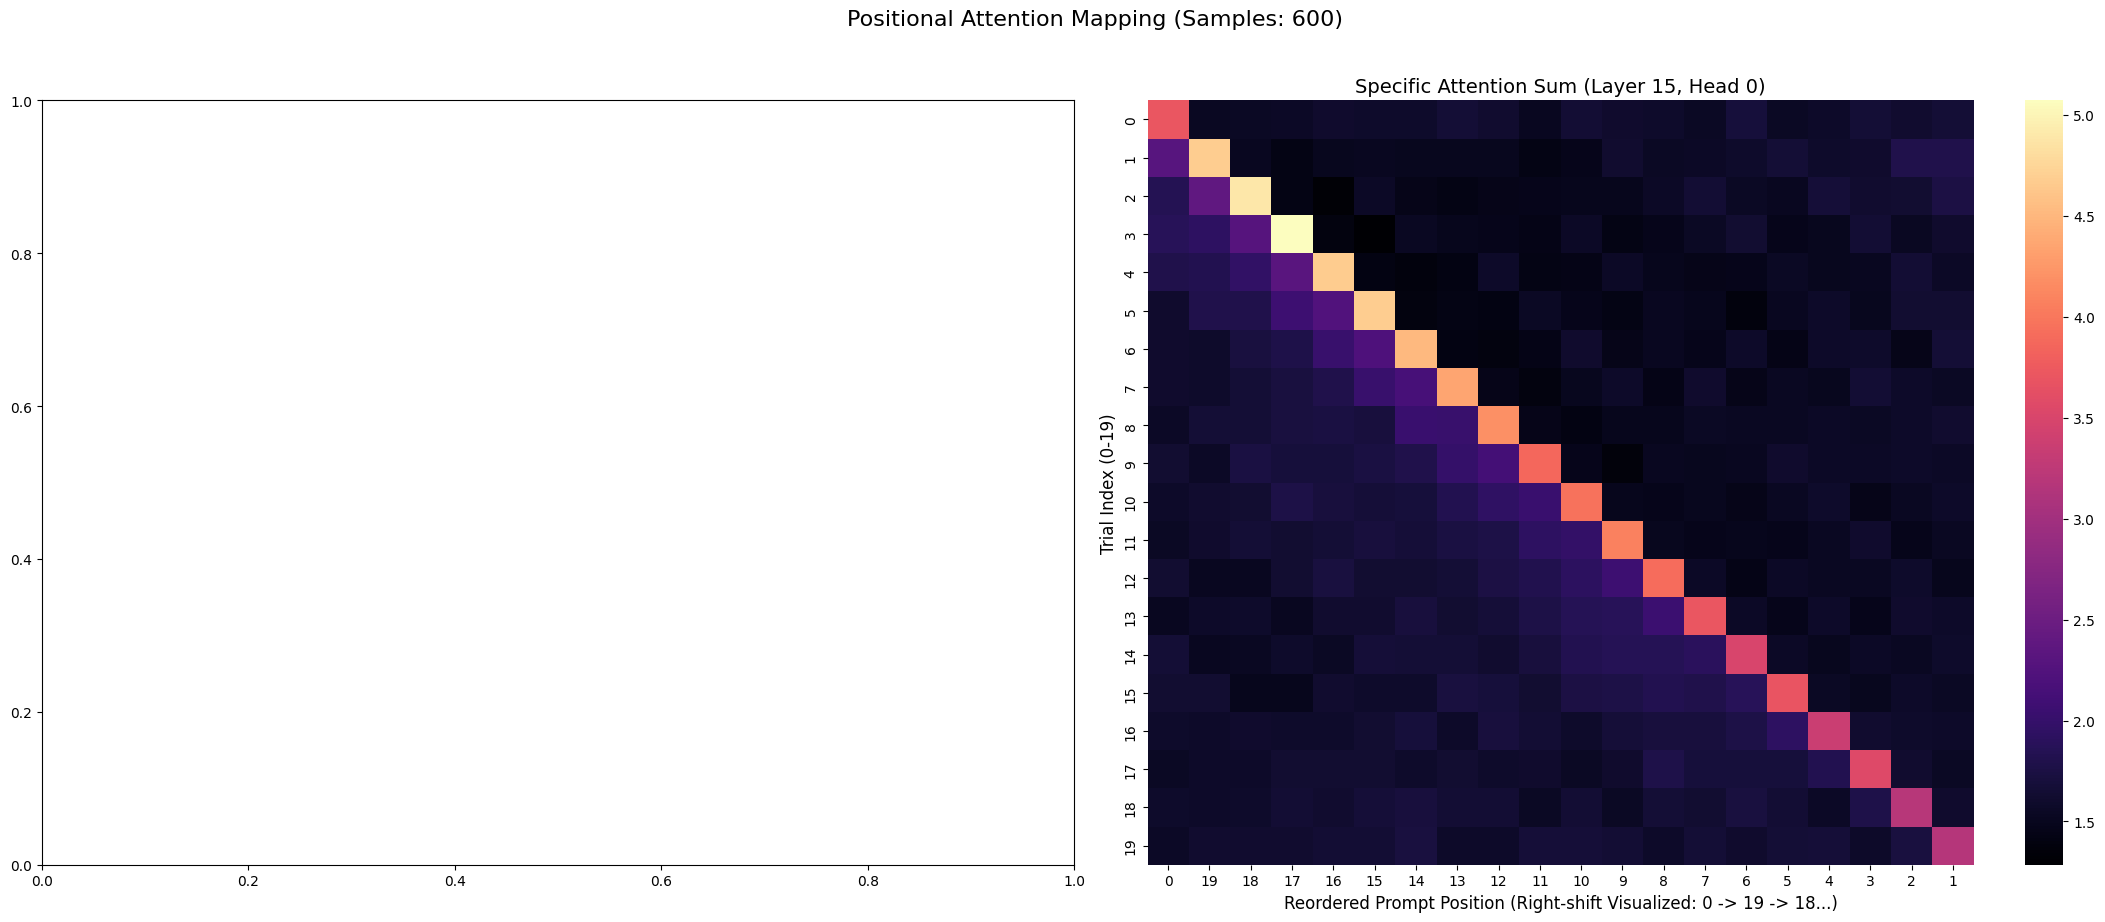

Loading data from /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/attn_maps/attnmap_shift_bm25_vicuna.jsonl...


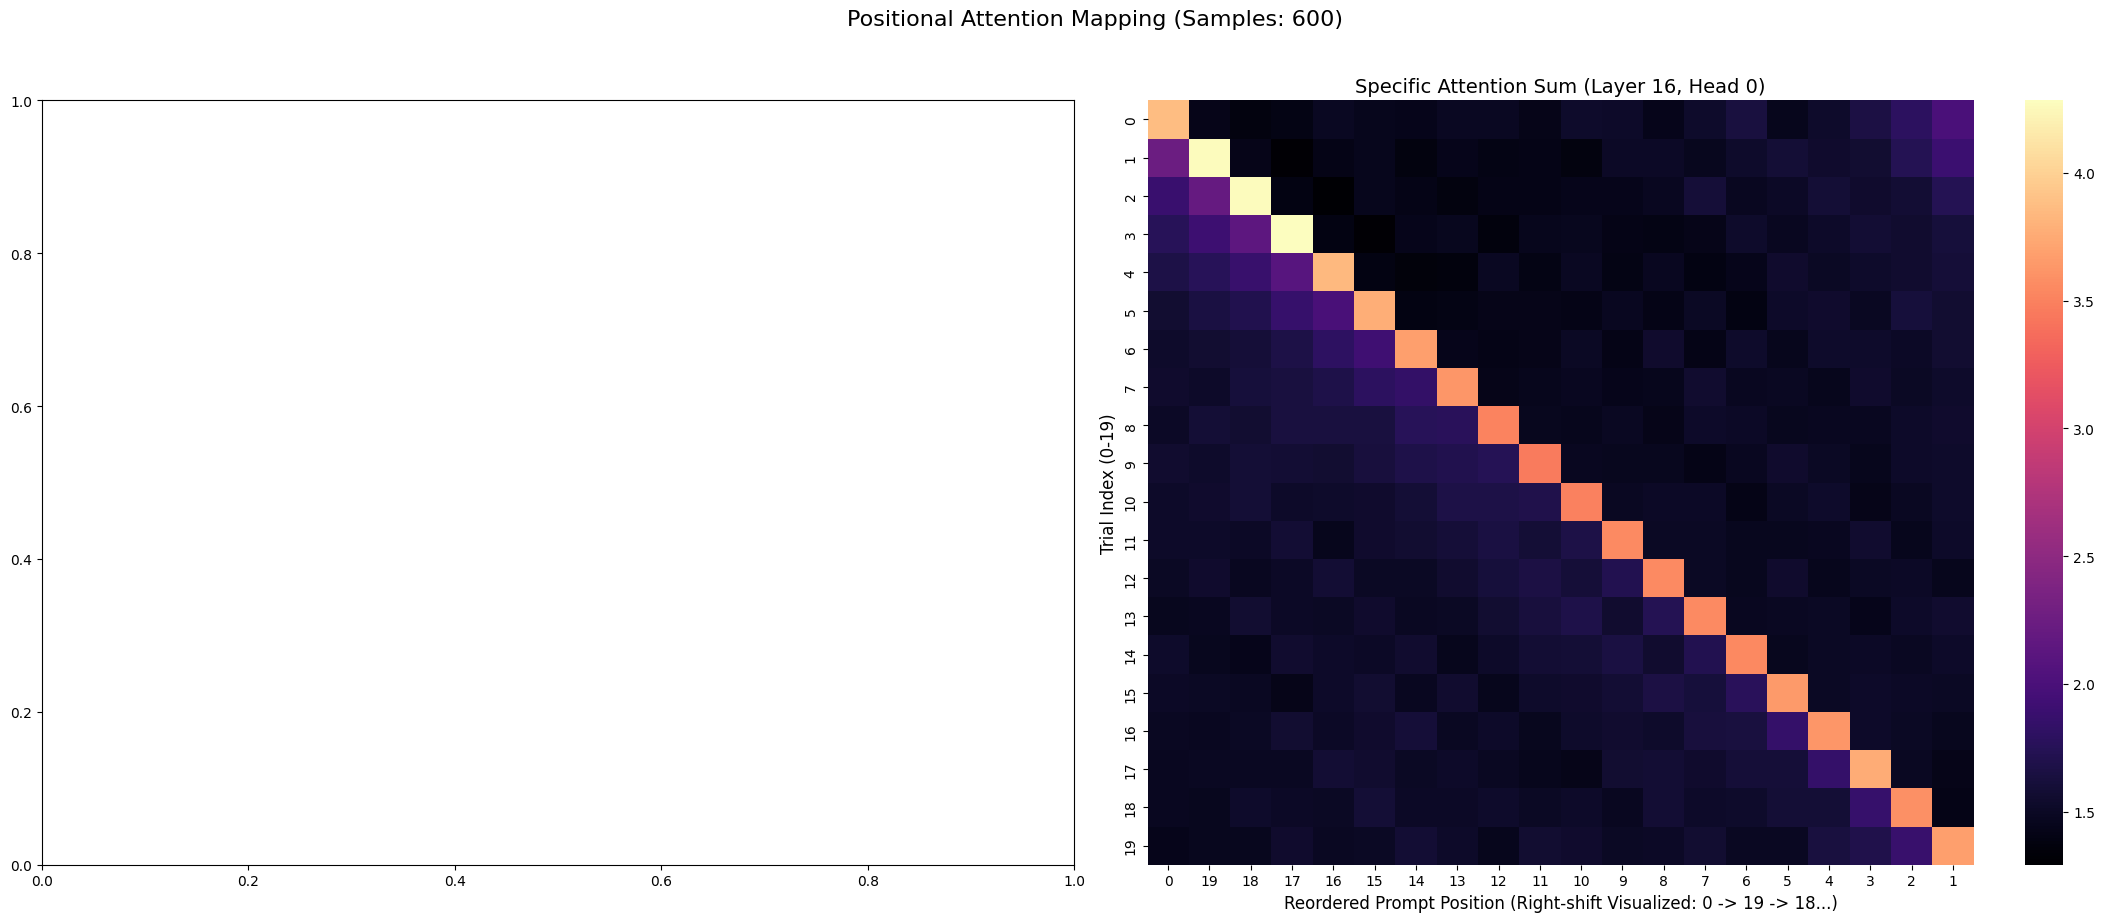

Loading data from /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/attn_maps/attnmap_shift_bm25_vicuna.jsonl...


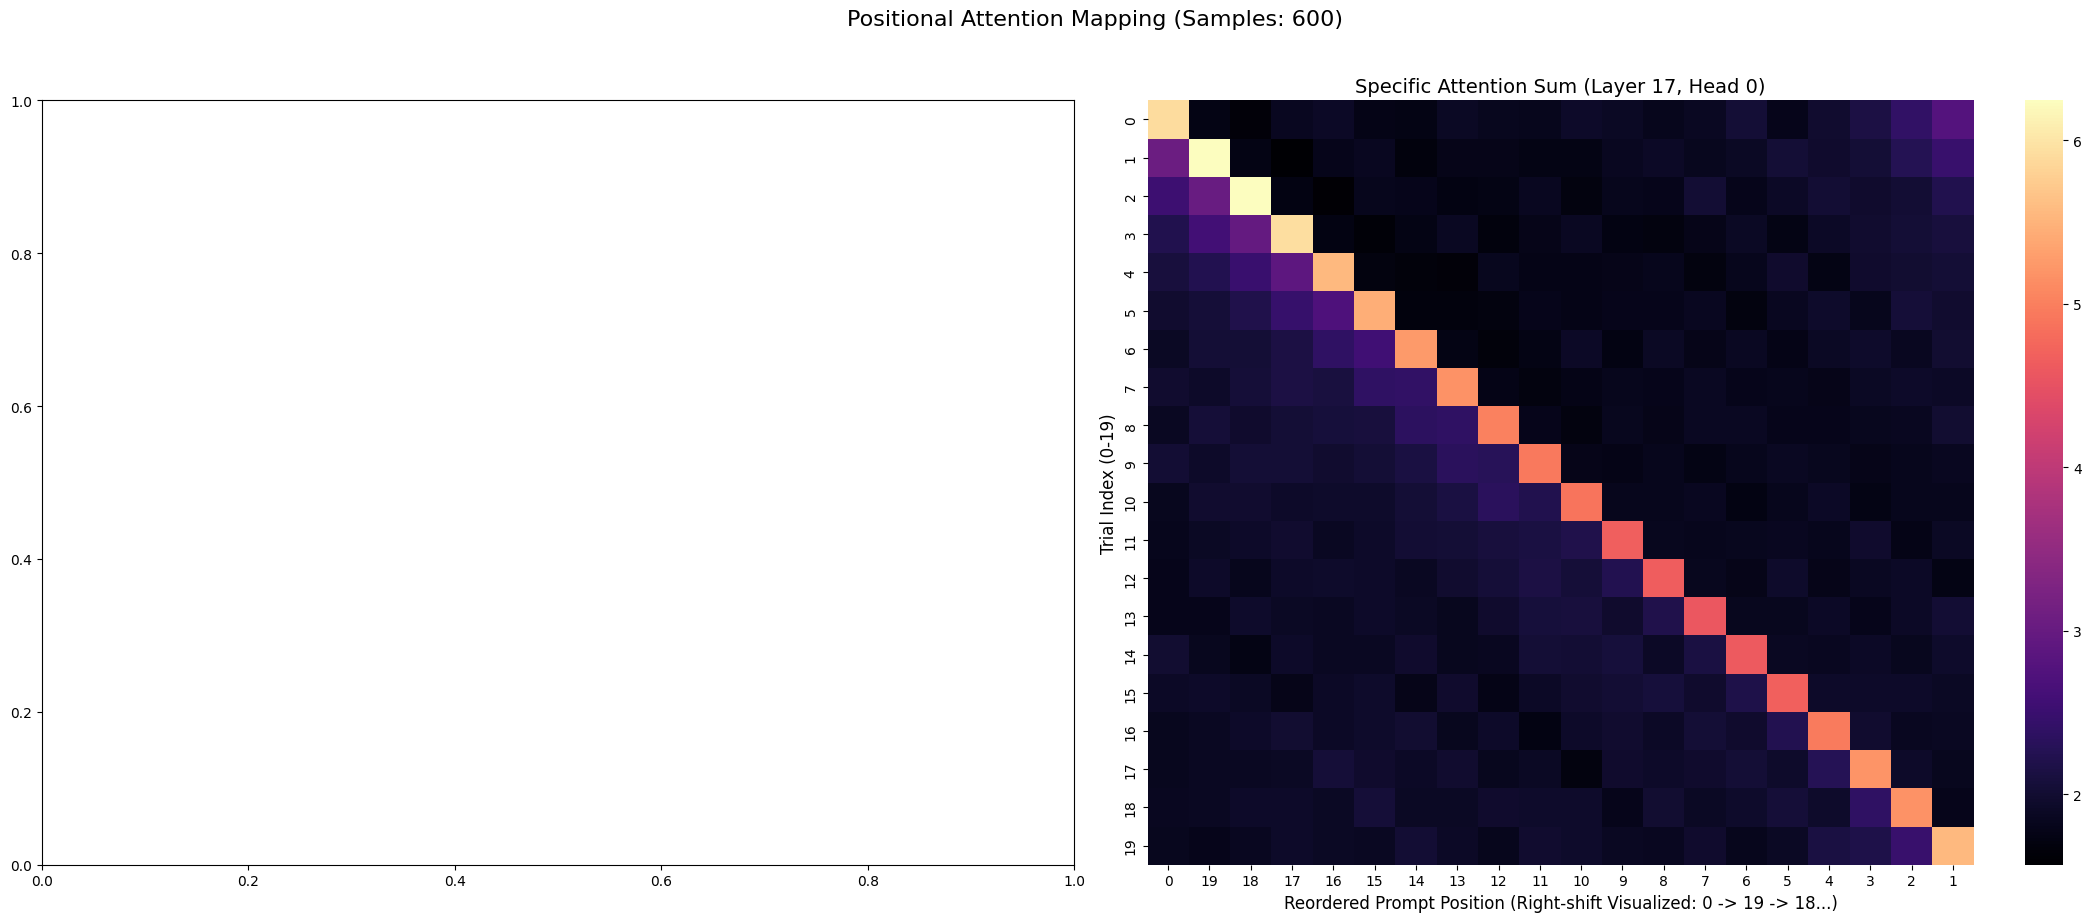

Loading data from /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/attn_maps/attnmap_shift_bm25_vicuna.jsonl...


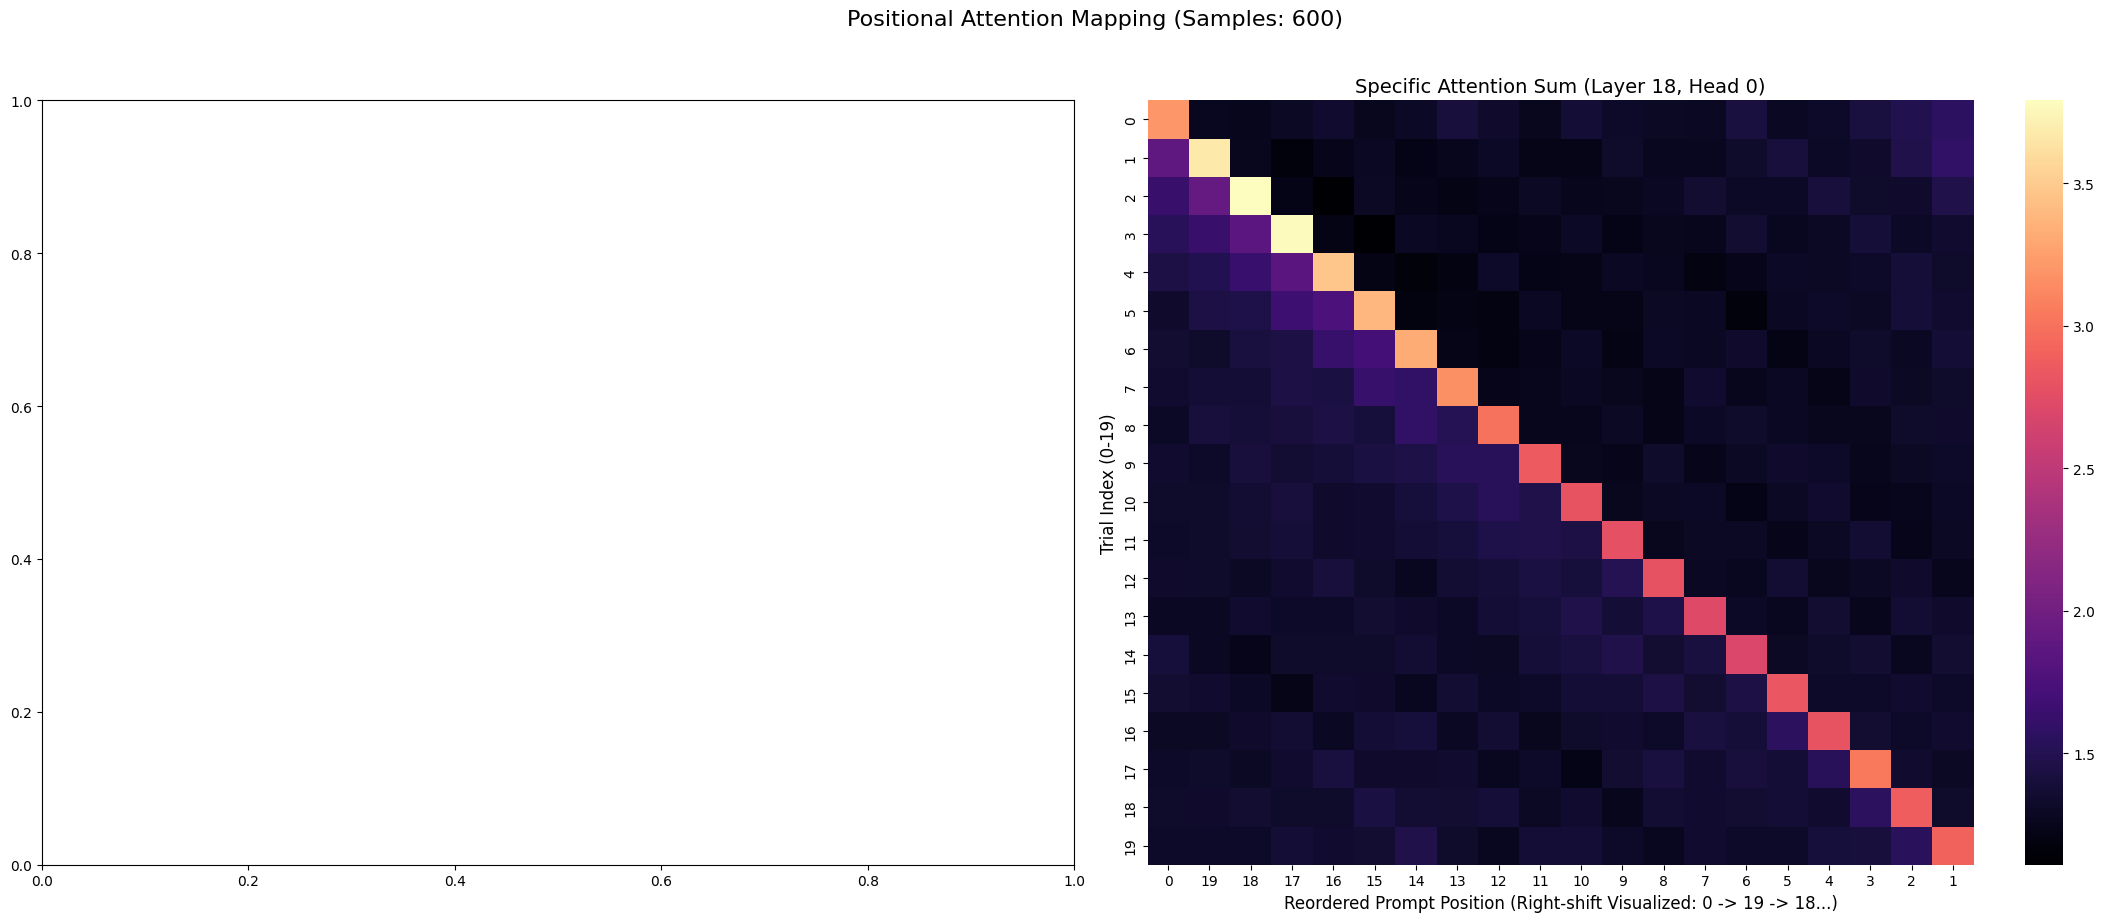

Loading data from /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/attn_maps/attnmap_shift_bm25_vicuna.jsonl...


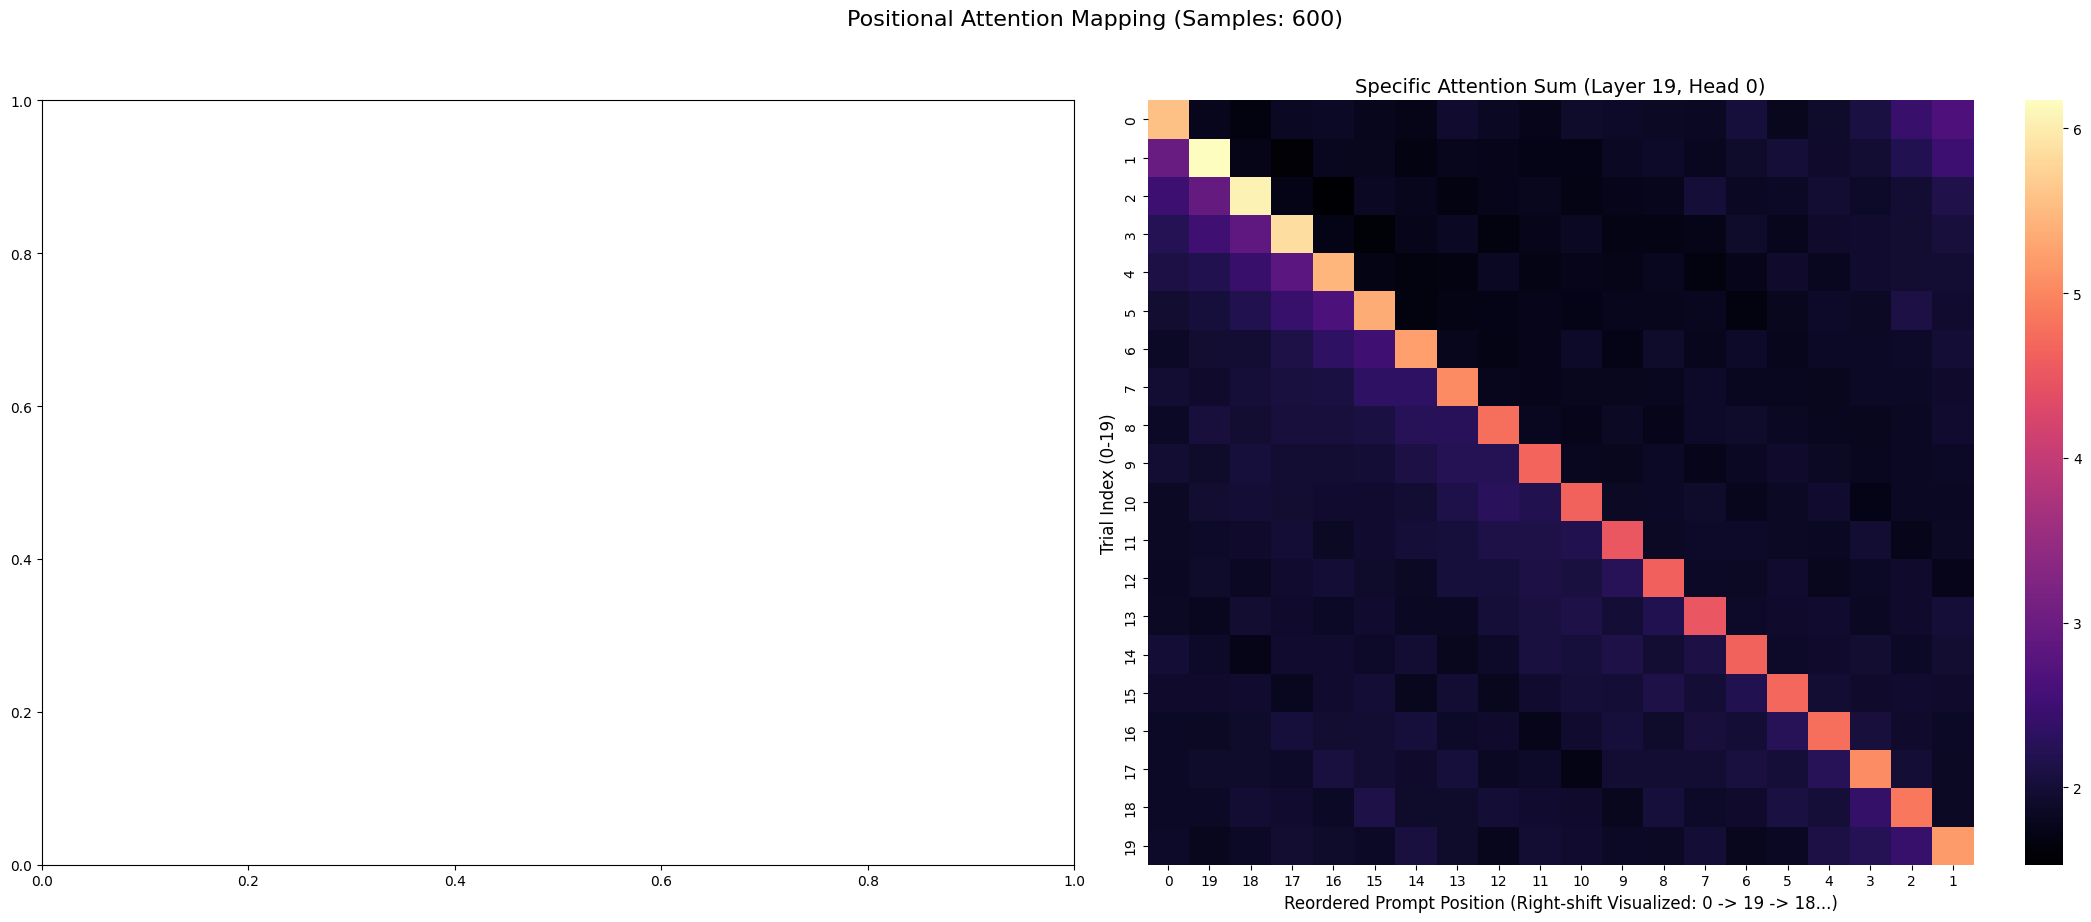

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_right_shift_visualized_heatmaps(file_path, target_layer=15, target_head=0, num_docs=20, layers_range=range(14, 20)):
    """
    左シフトのデータを、視覚的に右シフト(対角線が右下向き)に見えるように変換して描画する。
    X軸ラベルを [0, 19, 18, ..., 1] の順に並べることで実現。
    """
    # 1. データの集計 [試行, 文書, 層, ヘッド]
    accumulated_attn = np.zeros((num_docs, num_docs, len(layers_range), 32))
    sample_count = 0

    print(f"Loading data from {file_path}...")
    with open(file_path, "r") as f:
        for line in f:
            data = json.loads(line)
            attn_array = np.array(data["attnmap"])
            accumulated_attn += attn_array
            sample_count += 1

    # 2. プロンプト内位置への再配置 & 表示順(右シフト風)への変換
    # 描画用行列: [試行, 表示用列v]
    # v=0 に物理位置0, v=1 に物理位置19, v=2 に物理位置18... を配置
    sum_all_visual = np.zeros((num_docs, num_docs))
    sum_specific_visual = np.zeros((num_docs, num_docs))

    l_idx = list(layers_range).index(target_layer)

    for t in range(num_docs):
        for original_idx in range(num_docs):
            # 物理的な位置 P (0=先頭, 19=末尾)
            prompt_pos = (original_idx - t) % num_docs

            # 描画上の列 v への変換 (0->0, 19->1, 18->2, ..., 1->19)
            visual_v = (num_docs - prompt_pos) % num_docs

            # 全レイヤー・ヘッドの合計を累積
            # attn_val_all = accumulated_attn[t, original_idx, :, :].sum()
            # sum_all_visual[t, visual_v] += attn_val_all

            # 特定レイヤー・ヘッドの値を累積
            attn_val_spec = accumulated_attn[t, original_idx, l_idx, :].sum()
            sum_specific_visual[t, visual_v] += attn_val_spec

    # X軸のラベルを作成 [0, 19, 18, ..., 1]
    x_labels = [(num_docs - v) % num_docs for v in range(num_docs)]

    # 3. 描画
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))


    # マップ②: Specific
    sns.heatmap(sum_specific_visual, ax=ax2,
                xticklabels=x_labels, yticklabels=range(num_docs))
    ax2.set_title(f"Specific Attention Sum (Layer {target_layer})", fontsize=14)
    ax2.set_xlabel("Reordered Prompt Position (Right-shift Visualized: 0 -> 19 -> 18...)", fontsize=12)
    ax2.set_ylabel("Trial Index (0-19)", fontsize=12)

    plt.suptitle(f"Positional Attention Mapping (Samples: {sample_count})", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    return sum_all_visual, sum_specific_visual

# 実行
OUTPUT_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/attn_maps/attnmap_shift_bm25_vicuna.jsonl"
for i in range(15,20):
  total_map, head_map = plot_right_shift_visualized_heatmaps(OUTPUT_PATH, target_layer=i, target_head=0)

Loading data from /content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/test_attnmap_shift_bm25_vicuna-16k.jsonl...


22it [00:01, 15.14it/s]


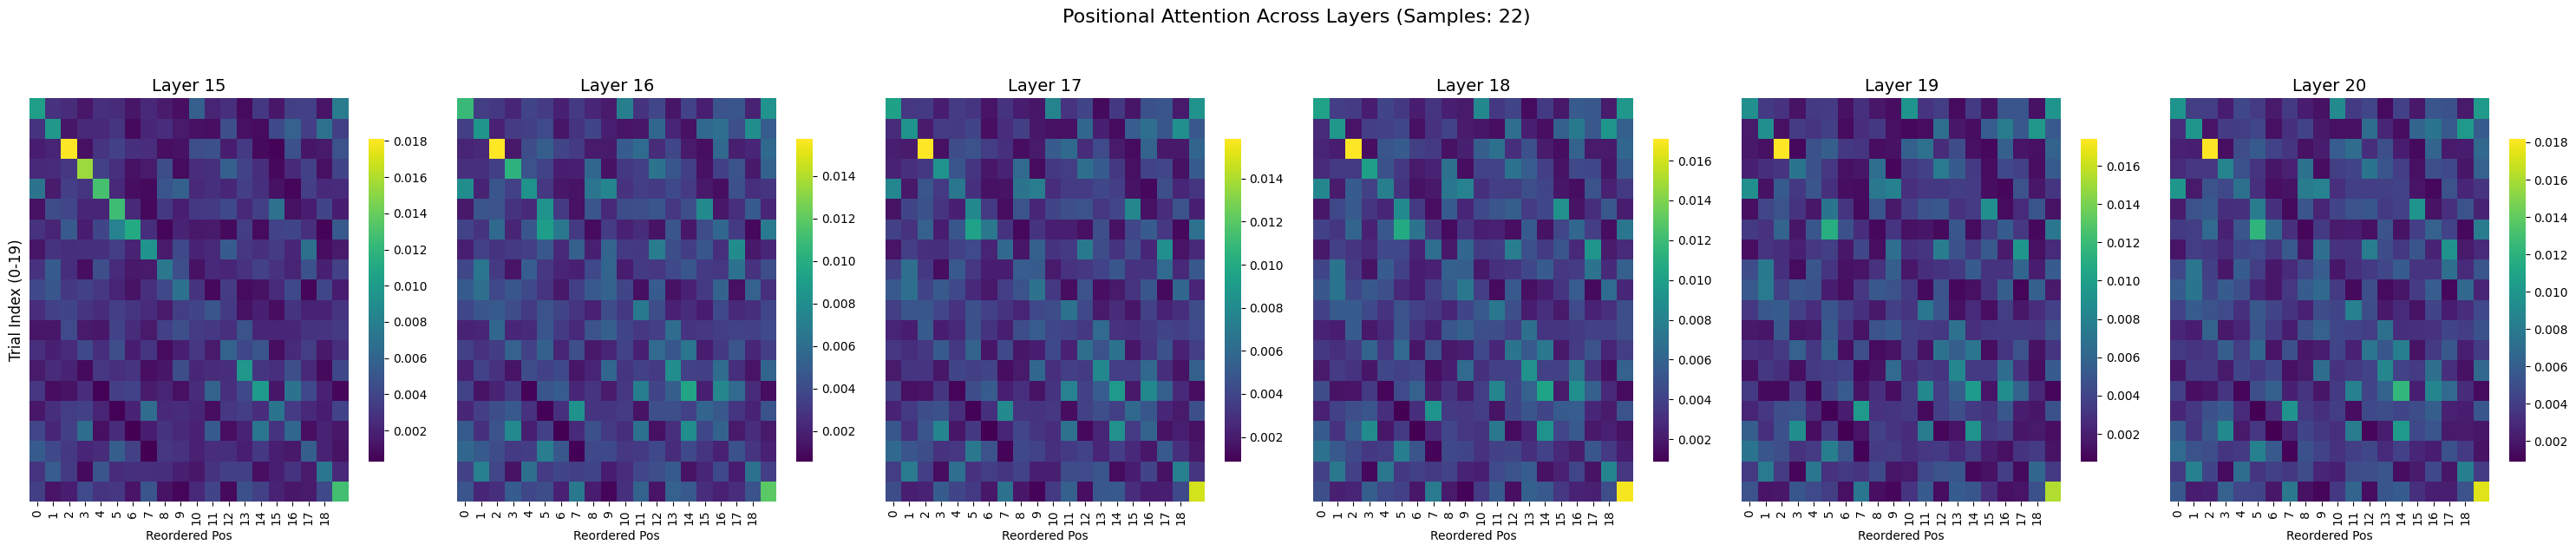

In [60]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def load_and_aggregate_attn(file_path, num_docs=20, layers_range=range(14, 20)):
    """JSONLからデータを一度だけ読み込み、試行×文書×層×ヘッドの平均を計算する"""
    # [試行t, 文書idx, 層, ヘッド]
    # メモリ節約のため float32 を使用
    accumulated_attn = np.zeros((num_docs, num_docs, len(layers_range), 32), dtype=np.float32)
    sample_count = 0

    print(f"Loading data from {file_path}...")
    with open(file_path, "r") as f:
        for i, line in tqdm(enumerate(f)):
            # if i != 0: continue
            if i > 22: break
            data = json.loads(line)
            # 一気に加算
            accumulated_attn += np.array(data["attnmap"], dtype=np.float32)
            sample_count += 1

    # 試行平均を取る
    return accumulated_attn / sample_count, sample_count

def transform_to_visual_matrix(accumulated_attn, layer_idx, num_docs=20):
    """
    特定のレイヤーのデータを、物理位置から描画用位置(右シフト)へ一気に変換する
    ベクトル演算を使用
    """
    # 特定レイヤー、全ヘッドの合計を取得 [trial_t, original_idx]
    # ユーザーの元のロジックに合わせ、全ヘッドを合計
    layer_data = accumulated_attn[:, :, layer_idx, :].sum(axis=-1)

    # 再配置用の空行列
    visual_matrix = np.zeros((num_docs, num_docs))

    for t in range(num_docs):
        # 物理位置 prompt_pos = (original_idx - t) % 20
        # 描画位置 visual_v = (20 - prompt_pos) % 20
        # これをまとめると: visual_v = (20 - (original_idx - t) % 20) % 20

        # original_idx [0...19] を一括変換
        orig_indices = np.arange(num_docs)
        prompt_pos = (orig_indices - t) % num_docs
        visual_v = (num_docs - prompt_pos) % num_docs

        # ベクトル代入
        visual_matrix[t, visual_v] = layer_data[t, orig_indices]

    return visual_matrix

def plot_heatmaps(accumulated_attn, layers_range, sample_count, num_docs=20):
    """全レイヤーをまとめて描画"""
    x_labels = [(num_docs - v) % num_docs for v in range(num_docs)]

    for i, layer_val in enumerate(layers_range):
        visual_matrix = transform_to_visual_matrix(accumulated_attn, i, num_docs)

        plt.figure(figsize=(10, 8))
        sns.heatmap(visual_matrix,xticklabels=x_labels, yticklabels=range(num_docs))

        plt.title(f"Specific Attention Sum (Layer {layer_val}) | Samples: {sample_count}")
        plt.xlabel("Reordered Prompt Position (0 -> 19 -> 18...)")
        plt.ylabel("Trial Index (0-19)")
        plt.tight_layout()
        plt.show()

# --- 実行セクション ---
OUTPUT_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/attn_maps/attnmap_shift_bm25_vicuna-16k.jsonl"
LAYERS = range(14, 20)

# 1. 読み込みは1回だけ！
agg_data, total_samples = load_and_aggregate_attn(OUTPUT_PATH, layers_range=LAYERS)

# 2. 描画
# plot_heatmaps(agg_data, LAYERS, total_samples)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_heatmaps_horizontal(accumulated_attn, layers_range, sample_count, num_docs=20):
    """5つのレイヤーのヒートマップを横一列に表示する"""
    num_plots = len(layers_range)
    # フィギュアのサイズを横長に設定 (横25, 縦5 程度がバランスが良いです)
    fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 6), sharey=True)

    x_labels = range(19)

    # 全レイヤーで色の基準（強さ）を合わせるための最大値取得（任意）
    # vmax = 0.5 # 強さを固定したい場合は数値を指定

    for i, layer_val in enumerate(layers_range):
        visual_matrix = transform_to_visual_matrix(accumulated_attn, i, num_docs)

        # ヒートマップの描画
        sns.heatmap(visual_matrix, ax=axes[i], cmap="viridis",
                    xticklabels=x_labels, # ラベル混雑防止
                    yticklabels=range(num_docs) if i == 0 else False,
                    cbar_kws={'shrink': 0.8})

        axes[i].set_title(f"Layer {layer_val}", fontsize=14)
        if i == 0:
            axes[i].set_ylabel("Trial Index (0-19)", fontsize=12)
        axes[i].set_xlabel("Reordered Pos", fontsize=10)

    plt.suptitle(f"Positional Attention Across Layers (Samples: {sample_count})", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# --- 実行 ---
# 前述の load_and_aggregate_attn で取得した agg_data を使用
LAYERS_TO_PLOT = range(15, 21) # 15, 16, 17, 18, 19, 20 の6つ
plot_heatmaps_horizontal(agg_data, LAYERS_TO_PLOT, total_samples)

2655it [00:05, 529.04it/s]


236


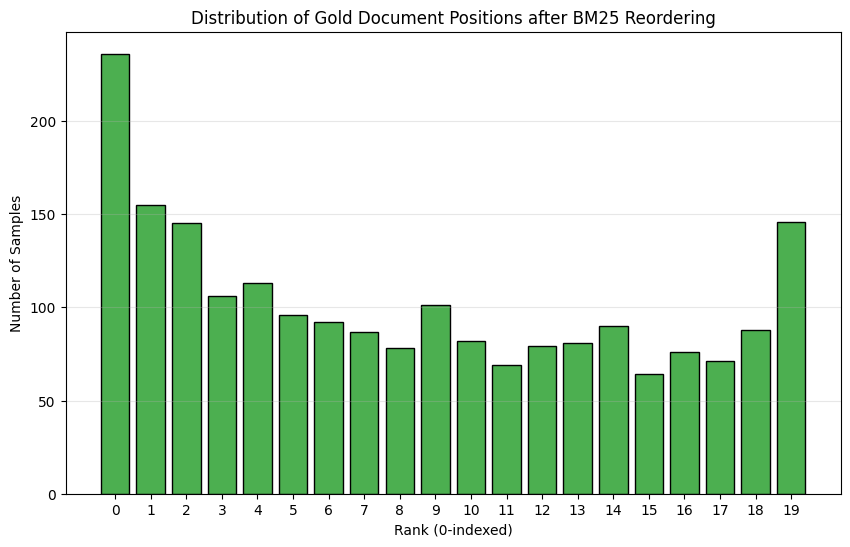

In [ ]:
import matplotlib.pyplot as plt
from copy import deepcopy
from tqdm import tqdm
from datasets.formatting.formatting import TypeVar
from typing import List, Optional, Type
from pydantic.dataclasses import dataclass
import json

%pip install rank_bm25
from rank_bm25 import BM25Okapi

%pip install xopen
from xopen import xopen

NQ_PATH = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/PositionalHidden/experiments/NQ/qa_data/20_total_documents/nq-open-20_total_documents_gold_at_0.jsonl.gz"
T = TypeVar("T")

@dataclass(frozen=True)
class Document:
    title: str
    text: str
    id: Optional[str] = None
    score: Optional[float] = None
    hasanswer: Optional[bool] = None
    isgold: Optional[bool] = None
    original_retrieval_index: Optional[int] = None

    @classmethod
    def from_dict(cls: Type[T], data: dict) -> T:
        data = deepcopy(data)
        if not data:
            raise ValueError("Must provide data for creation of Document from dict.")
        id = data.pop("id", None)
        score = data.pop("score", None)
        isgold = data.pop("isgold", None)
        # Convert score to float if it's provided.
        if score is not None:
            score = float(score)
        return cls(**dict(data, id=id, score=score, isgold=isgold))

def reorder_bm25(documents, question):
    """
    BM25スコアに基づいてドキュメントを降順に並び替える
    """
    if not documents:
        return []

    # 各ドキュメントを分割、小文字にしてリストで文章を格納
    tokenized_corpus = [doc.text.lower().split() for doc in documents]
    tokenized_query = question.lower().split()

    # bm25
    bm25 = BM25Okapi(tokenized_corpus)
    doc_scores = bm25.get_scores(tokenized_query)

    # スコアの降順（reverse=True）に並び替え
    reordered_docs = [doc for _, doc in sorted(zip(doc_scores, documents), reverse=True, key=lambda x: x[0])]

    return reordered_docs

NQ_path = f"/content/drive/MyDrive/Colab_Notebooks/graduate_research/PositionalHidden/experiments/NQ/qa_data/20_total_documents/nq-open-20_total_documents_gold_at_0.jsonl.gz"

def plot_gold_position_histogram(gold_positions, total_docs_count):
    """
    Gold文書の位置（インデックス）のリストを受け取り、ヒストグラムを表示する
    """
    plt.figure(figsize=(10, 6))

    # ヒストグラムの描画
    plt.hist(gold_positions, bins=range(total_docs_count + 1),
             align='left', rwidth=0.8, color='#4CAF50', edgecolor='black')

    plt.title('Distribution of Gold Document Positions after BM25 Reordering')
    plt.xlabel('Rank (0-indexed)')
    plt.ylabel('Number of Samples')
    plt.xticks(range(total_docs_count))
    plt.grid(axis='y', alpha=0.3)

    plt.show()

def main():
    all_gold_positions = [] # Gold文書のインデックスを保存する用
    total_docs_per_sample = 20 # ヒストグラムのX軸の範囲を決めるため

    with xopen(NQ_path, "r") as fin:
        for i, line in enumerate(tqdm(fin)):
            if i < 600: continue
            input = json.loads(line)
            question = input["question"]

            documents = []
            for ctx in deepcopy(input["ctxs"]):
                doc = Document.from_dict(ctx)
                documents.append(doc)

            documents = reorder_bm25(documents, question)

            for idx, doc in enumerate(documents):
                if getattr(doc, 'isgold', False):
                    all_gold_positions.append(idx)

    # 最後にヒストグラムを表示
    if all_gold_positions:
        print(all_gold_positions.count(0))
        plot_gold_position_histogram(all_gold_positions, total_docs_per_sample)
    else:
        print("Gold文書が一つも見つかりませんでした。Documentの属性名を確認してください。")

if __name__ == "__main__":
    main()